# Notebook 03 — Explainable AI (SHAP + LIME) (V2)
**Thesis**: A Prescriptive and Explainable Hybrid ML Framework for T2D Risk Prediction
**Dataset**: DiaHealth (single dataset)

### Checkpoint Strategy
- SHAP values: checkpoint `nb03_shap_diahealth.pkl` (slowest step)
- LIME explanations: checkpoint `nb03_lime_diahealth.pkl`
- AutoGluon is **excluded** from SHAP/LIME (no sklearn-compatible `predict_proba`)

### Sections
1. Imports
2. Load data & best model
3. SHAP global explanations
4. SHAP local explanations
5. SHAP dependence plots
6. SHAP subgroup analysis (by age, BMI)
7. LIME local explanations
8. SHAP vs LIME agreement
9. Save XAI results


In [ ]:
!pip install -q "scipy>=1.14.0,<1.17" "seaborn>=0.13.2" --upgrade
!pip install -q shap lime boruta dice-ml matplotlib

# Restart so upgraded scipy is loaded fresh into memory


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
import time
import shap
import lime
import lime.lime_tabular

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
print('All imports successful.')


All imports successful.


## 2. Load Data & Best Model

In [ ]:
# ============================================================
# 2. LOAD DATA AND BEST MODEL
# ============================================================
EXP_DIR       = '/kaggle/working/exp_v2'
PROCESSED_DIR = os.path.join(EXP_DIR, 'data', 'processed')
MODELS_DIR    = os.path.join(EXP_DIR, 'models')
XAI_DIR       = os.path.join(EXP_DIR, 'results', 'xai')
CKPT_DIR      = os.path.join(EXP_DIR, 'checkpoints')
os.makedirs(XAI_DIR, exist_ok=True)

d          = joblib.load(os.path.join(PROCESSED_DIR, 'diahealth_processed.pkl'))
X_train    = d['X_train_res_boruta']
X_test     = d['X_test_boruta']
y_train    = d['y_train_res']
y_test     = d['y_test']
FEATURES   = d['feature_names_boruta']
TARGET_COL = d['target_col']

# Load best model name and corresponding model
best_info = joblib.load(os.path.join(MODELS_DIR, 'best_model_info.pkl'))
best_name = best_info['diahealth']
print(f'Best model: {best_name}')

MODEL_FILES = {
    'XGBoost':  'diahealth_xgboost.pkl',
    'LightGBM': 'diahealth_lightgbm.pkl',
    'CatBoost': 'diahealth_catboost.pkl',
}

# Load all tree models (AutoGluon excluded — no TreeExplainer support)
models = {}
for name, fname in MODEL_FILES.items():
    fpath = os.path.join(MODELS_DIR, fname)
    if os.path.exists(fpath):
        models[name] = joblib.load(fpath)
        print(f'  Loaded {name}')

# Prefer best model; fall back to XGBoost
model_name = best_name if best_name in models else 'XGBoost'
model      = models[model_name]
print(f'\nUsing for XAI: {model_name}')
print(f'Test shape   : {X_test.shape}  Features: {FEATURES}')


Best model: AutoGluon
  Loaded XGBoost
  Loaded LightGBM
  Loaded CatBoost

Using for XAI: XGBoost
Test shape   : (1088, 16)  Features: ['age', 'gender', 'pulse_rate', 'systolic_bp', 'diastolic_bp', 'glucose', 'weight', 'bmi', 'hypertensive', 'bp_ratio', 'pulse_pressure', 'bmi_age', 'glucose_bmi', 'cardio_risk', 'family_hypertension', 'family_risk']


## 3. SHAP Global Explanations (checkpoint)

Computing SHAP values (TreeExplainer)...
  Done in 1.4s  shape=(1088, 16)
  Checkpoint saved -> /kaggle/working/exp_v2/checkpoints/nb03_shap_diahealth.pkl


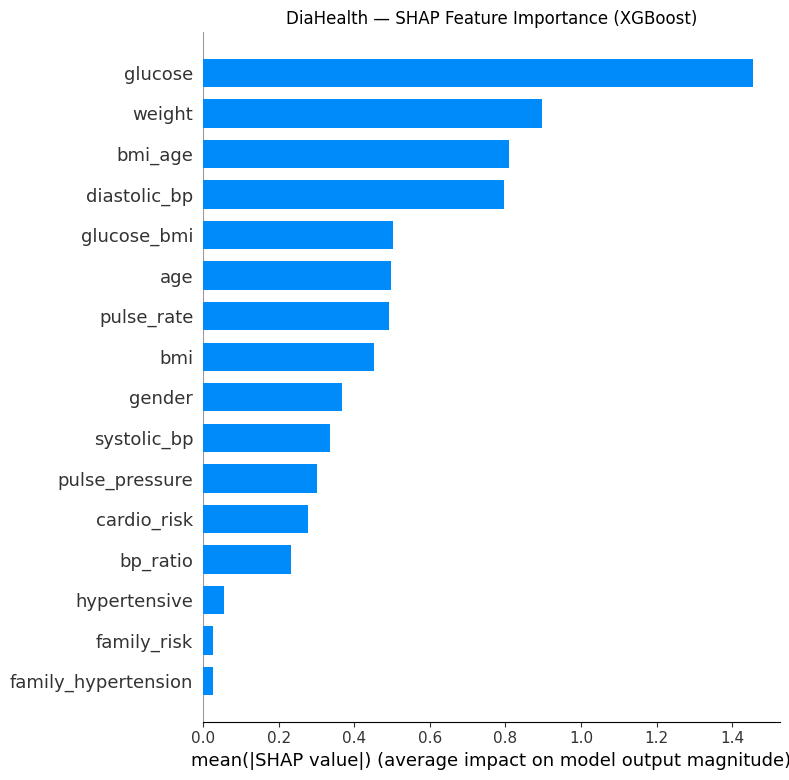

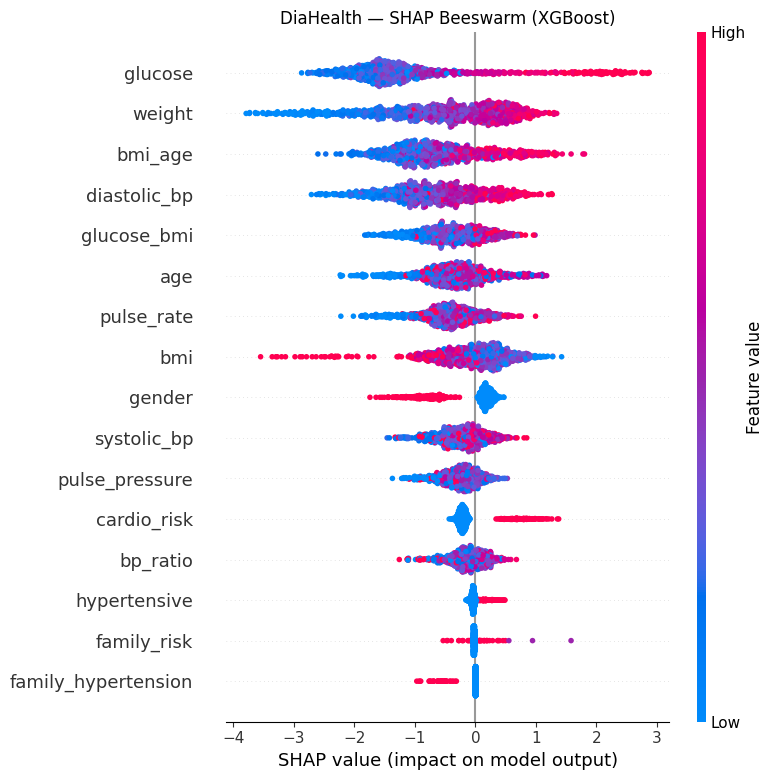


Top features by mean |SHAP|:
glucose                1.4538
weight                 0.8955
bmi_age                0.8107
diastolic_bp           0.7974
glucose_bmi            0.5013
age                    0.4979
pulse_rate             0.4932
bmi                    0.4529
gender                 0.3678
systolic_bp            0.3366
pulse_pressure         0.3009
cardio_risk            0.2772
bp_ratio               0.2319
hypertensive           0.0554
family_risk            0.0272
family_hypertension    0.0264
dtype: float32


In [ ]:
# ============================================================
# 3. SHAP GLOBAL EXPLANATIONS (TreeExplainer — checkpoint)
# ============================================================

def normalize_shap(sv):
    """Convert 3D SHAP (n, f, 2) to 2D positive-class (n, f)."""
    if isinstance(sv, list):
        sv = sv[1] if len(sv) == 2 else sv[0]
    if hasattr(sv, 'values'):
        sv = sv.values
    arr = np.array(sv)
    if arr.ndim == 3 and arr.shape[2] == 2:
        arr = arr[:, :, 1]
    return arr

CKPT_SHAP = os.path.join(CKPT_DIR, 'nb03_shap_diahealth.pkl')

if os.path.exists(CKPT_SHAP):
    ckpt_data    = joblib.load(CKPT_SHAP)
    shap_values  = ckpt_data['shap_values']
    X_test_shap  = ckpt_data['X_test_shap']
    print(f'SHAP loaded from checkpoint  shape={shap_values.shape}')
else:
    print('Computing SHAP values (TreeExplainer)...')
    t0 = time.time()
    X_test_shap = X_test.copy()
    explainer   = shap.TreeExplainer(model)
    sv_raw      = explainer.shap_values(X_test_shap)
    shap_values = normalize_shap(sv_raw)
    print(f'  Done in {time.time()-t0:.1f}s  shape={shap_values.shape}')
    joblib.dump({'shap_values': shap_values, 'X_test_shap': X_test_shap}, CKPT_SHAP)
    print(f'  Checkpoint saved -> {CKPT_SHAP}')

# --- Global SHAP summary plot ---
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_shap, feature_names=FEATURES,
                  plot_type='bar', show=False)
plt.title(f'DiaHealth — SHAP Feature Importance ({model_name})')
plt.tight_layout()
plt.savefig(os.path.join(XAI_DIR, 'shap_global_bar.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_shap, feature_names=FEATURES, show=False)
plt.title(f'DiaHealth — SHAP Beeswarm ({model_name})')
plt.tight_layout()
plt.savefig(os.path.join(XAI_DIR, 'shap_global_beeswarm.png'), dpi=150, bbox_inches='tight')
plt.show()

shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURES)
print('\nTop features by mean |SHAP|:')
print(shap_importance.sort_values(ascending=False).round(4))


## 4. SHAP Local Explanations

Instance 0: true=0  prob=0.0022


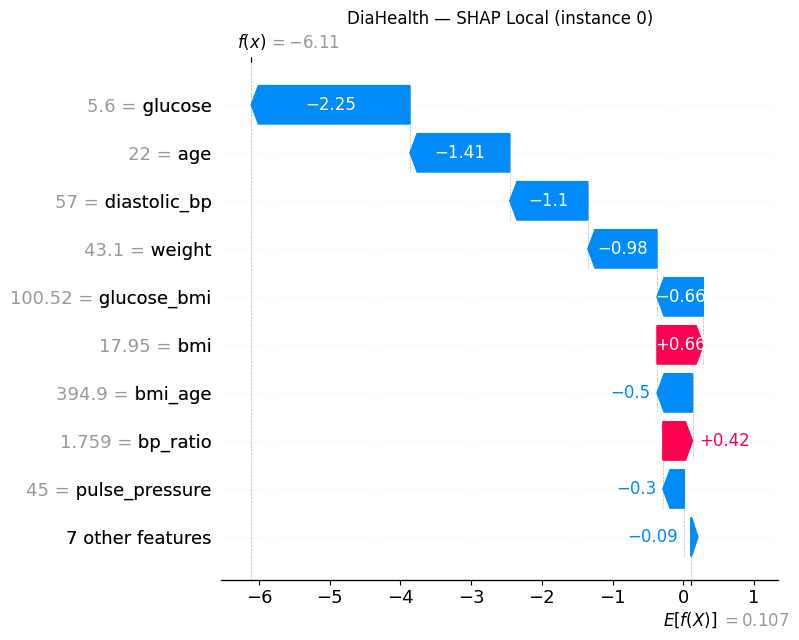

Instance 1: true=1  prob=0.1643


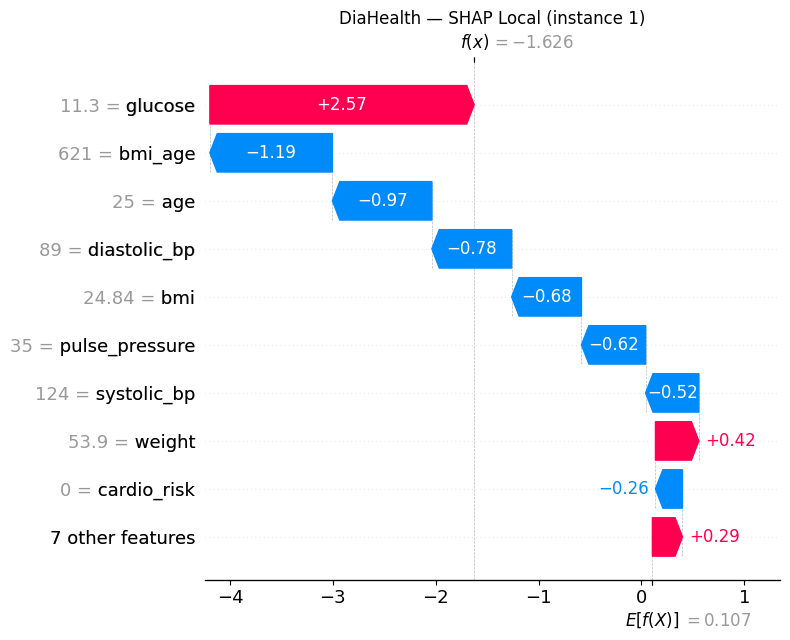

Instance 2: true=0  prob=0.0002


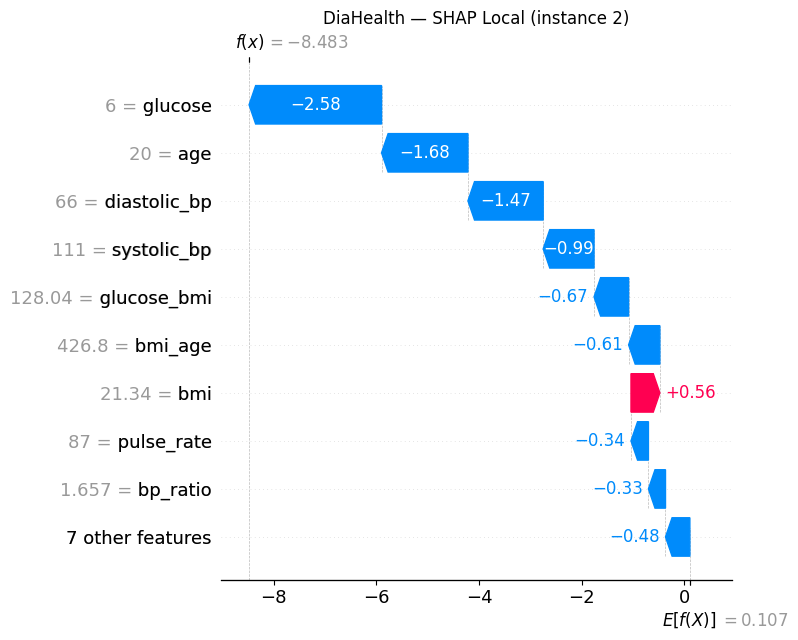

SHAP local explanations done.


In [ ]:
# ============================================================
# 4. SHAP LOCAL EXPLANATIONS (waterfall for top-3 instances)
# ============================================================
n_local = min(3, len(X_test_shap))
explainer_local = shap.TreeExplainer(model)

for i in range(n_local):
    exp = explainer_local(X_test_shap.iloc[[i]])
    sv_i = normalize_shap(exp.values)
    print(f'Instance {i}: true={y_test.iloc[i]}  '
          f'prob={model.predict_proba(X_test_shap.iloc[[i]])[0, 1]:.4f}')
    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(
        shap.Explanation(
            values=sv_i[0],
            base_values=exp.base_values[0] if hasattr(exp.base_values, '__len__') else exp.base_values,
            data=X_test_shap.iloc[i].values,
            feature_names=FEATURES,
        ),
        show=False,
    )
    plt.title(f'DiaHealth — SHAP Local (instance {i})')
    plt.tight_layout()
    plt.savefig(os.path.join(XAI_DIR, f'shap_local_{i}.png'), dpi=150, bbox_inches='tight')
    plt.show()

print('SHAP local explanations done.')


## 5. SHAP Dependence Plots

<Figure size 800x500 with 0 Axes>

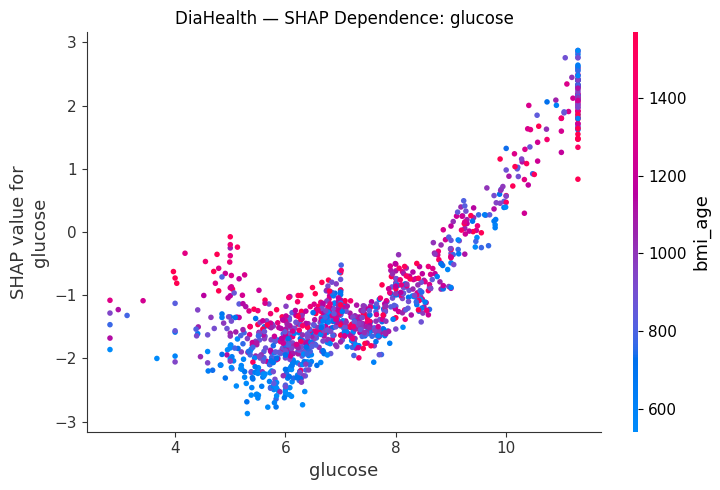

  Dependence plot saved: glucose


<Figure size 800x500 with 0 Axes>

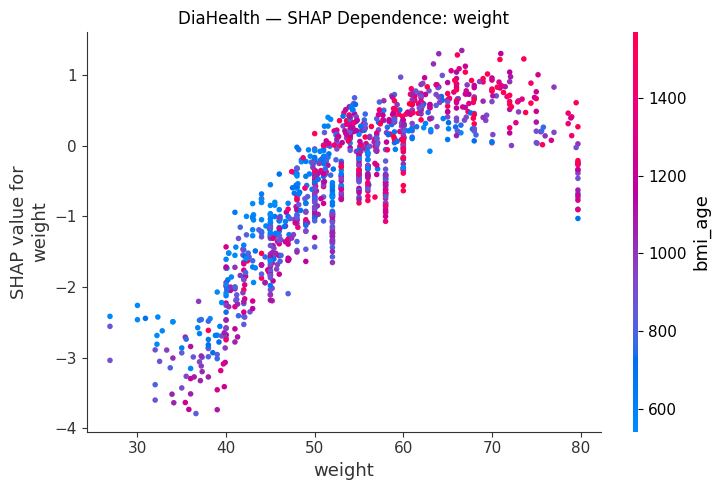

  Dependence plot saved: weight


<Figure size 800x500 with 0 Axes>

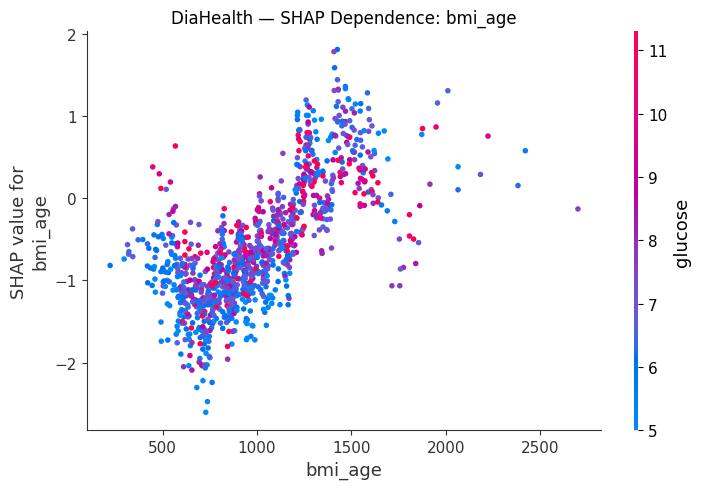

  Dependence plot saved: bmi_age
SHAP dependence plots done.


In [ ]:
# ============================================================
# 5. SHAP DEPENDENCE PLOTS (top-3 features)
# ============================================================
top3_features = shap_importance.sort_values(ascending=False).head(3).index.tolist()

for feat in top3_features:
    fi = FEATURES.index(feat)
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(fi, shap_values, X_test_shap, show=False)
    plt.title(f'DiaHealth — SHAP Dependence: {feat}')
    plt.tight_layout()
    plt.savefig(os.path.join(XAI_DIR, f'shap_dep_{feat.replace(".", "_")}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Dependence plot saved: {feat}')

print('SHAP dependence plots done.')


## 6. SHAP Subgroup Analysis

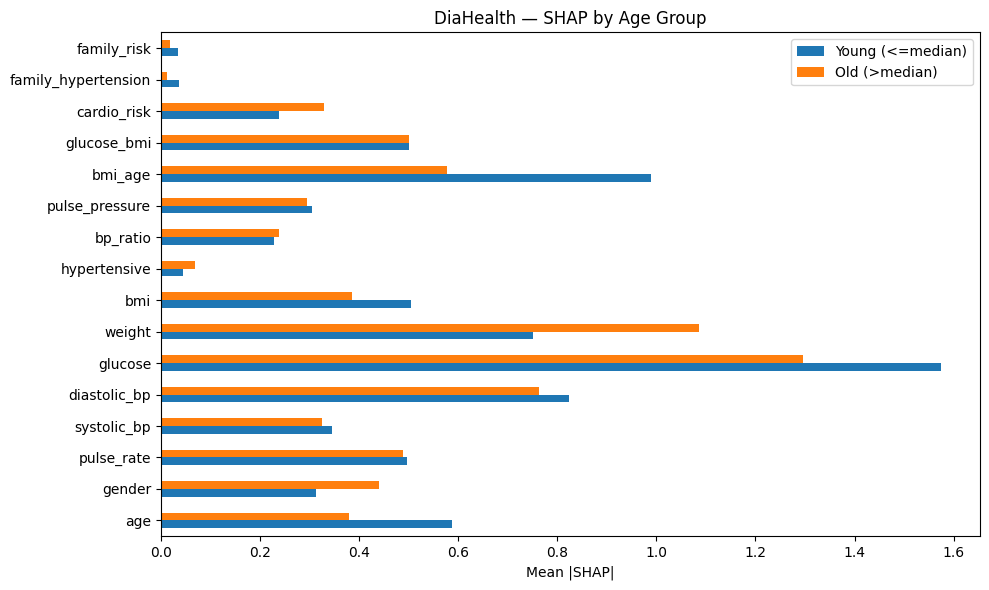

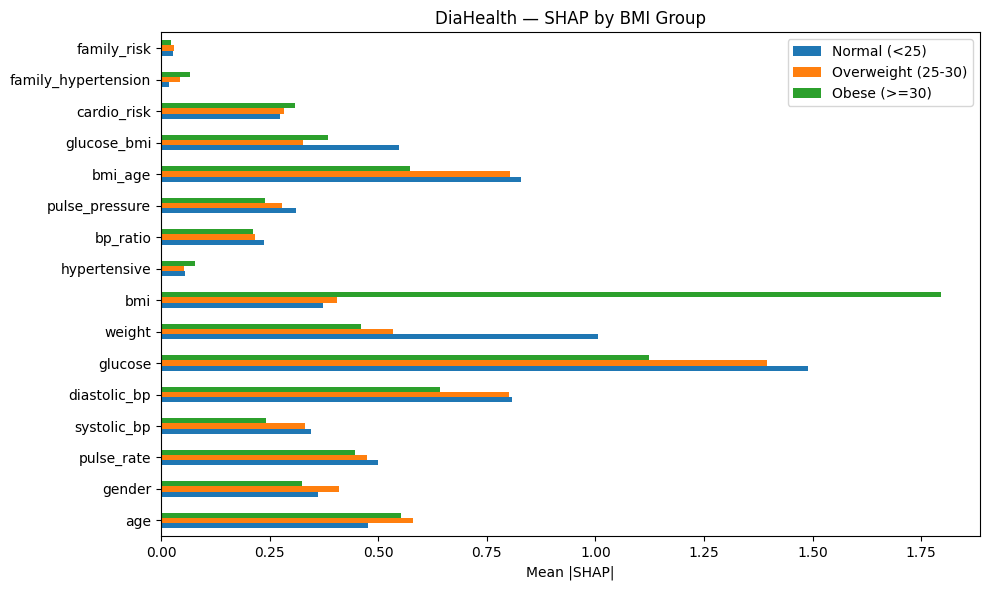

SHAP subgroup analysis done.


In [ ]:
# ============================================================
# 6. SHAP SUBGROUP ANALYSIS (age and BMI)
# ============================================================

# --- By Age ---
age_cols = [c for c in FEATURES if 'age' in c.lower()]
if age_cols:
    col = age_cols[0]
    med = X_test_shap[col].median()
    mask_young = X_test_shap[col].values <= med
    mask_old   = X_test_shap[col].values > med
    young_imp  = pd.Series(np.abs(shap_values[mask_young]).mean(axis=0), index=FEATURES)
    old_imp    = pd.Series(np.abs(shap_values[mask_old]).mean(axis=0),   index=FEATURES)
    pd.DataFrame({'Young (<=median)': young_imp, 'Old (>median)': old_imp}).plot(
        kind='barh', figsize=(10, 6))
    plt.title('DiaHealth — SHAP by Age Group')
    plt.xlabel('Mean |SHAP|')
    plt.tight_layout()
    plt.savefig(os.path.join(XAI_DIR, 'shap_subgroup_age.png'), dpi=150)
    plt.show()

# --- By BMI ---
bmi_cols = [c for c in FEATURES if 'bmi' in c.lower()]
if bmi_cols:
    col = bmi_cols[0]
    groups = {}
    m1 = X_test_shap[col] < 25
    m2 = (X_test_shap[col] >= 25) & (X_test_shap[col] < 30)
    m3 = X_test_shap[col] >= 30
    if m1.sum() > 5:
        groups['Normal (<25)']      = pd.Series(np.abs(shap_values[m1.values]).mean(axis=0), index=FEATURES)
    if m2.sum() > 5:
        groups['Overweight (25-30)'] = pd.Series(np.abs(shap_values[m2.values]).mean(axis=0), index=FEATURES)
    if m3.sum() > 5:
        groups['Obese (>=30)']      = pd.Series(np.abs(shap_values[m3.values]).mean(axis=0), index=FEATURES)
    if groups:
        pd.DataFrame(groups).plot(kind='barh', figsize=(10, 6))
        plt.title('DiaHealth — SHAP by BMI Group')
        plt.xlabel('Mean |SHAP|')
        plt.tight_layout()
        plt.savefig(os.path.join(XAI_DIR, 'shap_subgroup_bmi.png'), dpi=150)
        plt.show()

print('SHAP subgroup analysis done.')


## 7. LIME Local Explanations (checkpoint)

Computing LIME explanations...


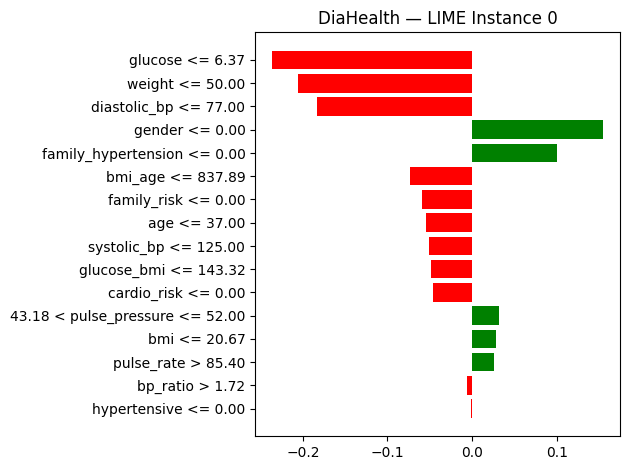

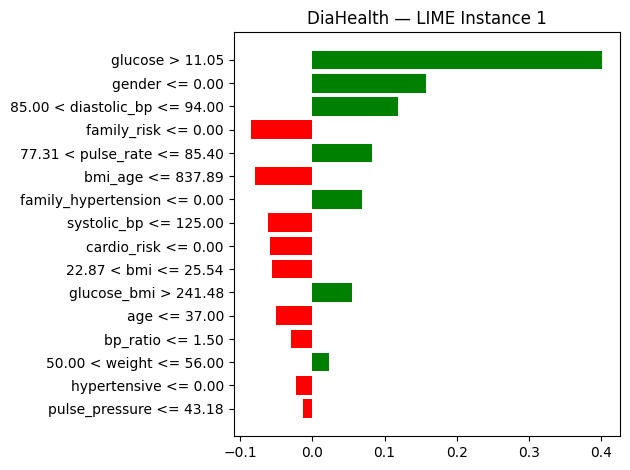

  Checkpoint saved (5 explanations)
LIME done.


In [ ]:
# ============================================================
# 7. LIME LOCAL EXPLANATIONS (checkpoint)
# ============================================================
CKPT_LIME = os.path.join(CKPT_DIR, 'nb03_lime_diahealth.pkl')

if os.path.exists(CKPT_LIME):
    lime_results = joblib.load(CKPT_LIME)
    print(f'LIME loaded from checkpoint ({len(lime_results)} explanations)')
else:
    print('Computing LIME explanations...')
    lime_exp = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train.values,
        feature_names=FEATURES,
        class_names=['Non-diabetic', 'Diabetic'],
        mode='classification',
        random_state=RANDOM_STATE,
    )
    n_explain    = min(5, len(X_test))
    lime_results = []
    for i in range(n_explain):
        exp = lime_exp.explain_instance(
            X_test_shap.iloc[i].values,
            model.predict_proba,
            num_features=len(FEATURES),
        )
        lime_results.append(exp)
        if i < 2:
            fig = exp.as_pyplot_figure()
            plt.title(f'DiaHealth — LIME Instance {i}')
            plt.tight_layout()
            plt.savefig(os.path.join(XAI_DIR, f'lime_instance_{i}.png'),
                        dpi=150, bbox_inches='tight')
            plt.show()
    joblib.dump(lime_results, CKPT_LIME)
    print(f'  Checkpoint saved ({len(lime_results)} explanations)')

print('LIME done.')


## 8. SHAP vs LIME Agreement

SHAP vs LIME Top-Feature Agreement:
  Top-3: 1/3 overlap (33%)  common=['glucose']
  Top-5: 3/5 overlap (60%)  common=['diastolic_bp', 'glucose', 'weight']


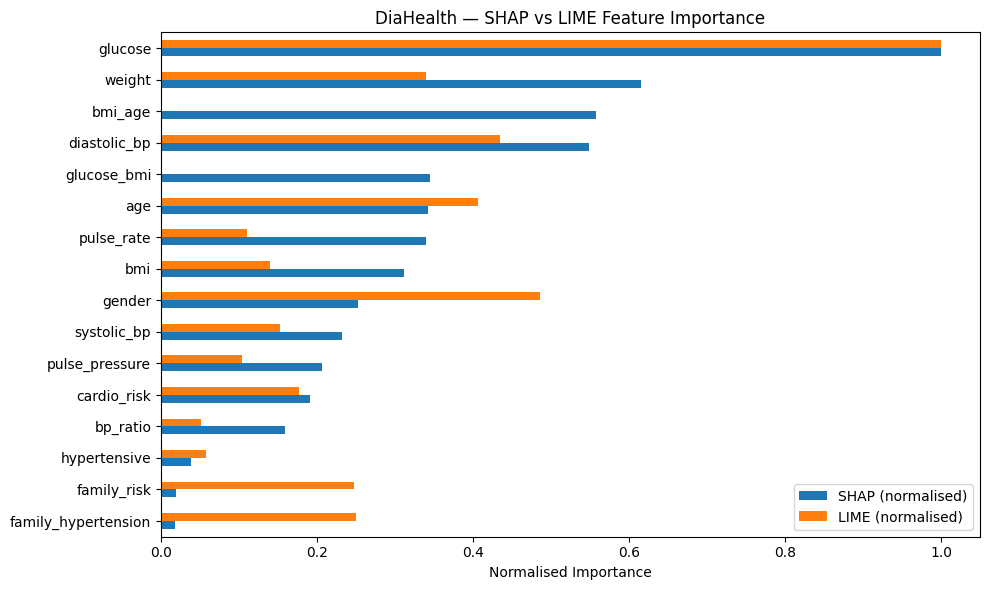

Agreement analysis done.


In [ ]:
# ============================================================
# 8. SHAP vs LIME AGREEMENT
# ============================================================
shap_imp  = shap_importance.copy()
shap_rank = shap_imp.sort_values(ascending=False).index.tolist()

lime_imp  = pd.Series(0.0, index=FEATURES)
for exp in lime_results:
    for fn, w in exp.as_list():
        for f in FEATURES:
            if f in fn:
                lime_imp[f] += abs(w)
                break
lime_imp /= max(len(lime_results), 1)
lime_rank = lime_imp.sort_values(ascending=False).index.tolist()

print('SHAP vs LIME Top-Feature Agreement:')
for K in [3, 5]:
    K_ = min(K, len(FEATURES))
    overlap = set(shap_rank[:K_]) & set(lime_rank[:K_])
    print(f'  Top-{K_}: {len(overlap)}/{K_} overlap ({len(overlap)/K_*100:.0f}%)  '
          f'common={sorted(overlap)}')

# Comparison chart
comp = pd.DataFrame({
    'SHAP (normalised)': shap_imp / (shap_imp.max() + 1e-10),
    'LIME (normalised)': lime_imp / (lime_imp.max() + 1e-10),
})
comp.sort_values('SHAP (normalised)', ascending=True).plot(kind='barh', figsize=(10, 6))
plt.title('DiaHealth — SHAP vs LIME Feature Importance')
plt.xlabel('Normalised Importance')
plt.tight_layout()
plt.savefig(os.path.join(XAI_DIR, 'shap_vs_lime.png'), dpi=150)
plt.show()

agreement_result = {'shap_ranking': shap_rank, 'lime_ranking': lime_rank}
print('Agreement analysis done.')


## 9. Save XAI Results

In [ ]:
# ============================================================
# 9. SAVE XAI RESULTS
# ============================================================
xai_output = {
    'shap_values':       shap_values,
    'X_test_shap':       X_test_shap,
    'model_name':        model_name,
    'shap_importance':   shap_importance.to_dict(),
    'agreement_result':  agreement_result,
    'top5_features':     shap_importance.sort_values(ascending=False).head(5).to_dict(),
}
joblib.dump(xai_output, os.path.join(XAI_DIR, 'xai_results.pkl'))

print(f'XAI results saved to {XAI_DIR}')
plots = [f for f in os.listdir(XAI_DIR) if f.endswith('.png')]
print(f'  Plots generated: {len(plots)}')
for p in sorted(plots):
    print(f'    {p}')
print()
print('Notebook 03 complete! Proceed to 04_counterfactuals.ipynb')


XAI results saved to /kaggle/working/exp_v2/results/xai
  Plots generated: 13
    lime_instance_0.png
    lime_instance_1.png
    shap_dep_bmi_age.png
    shap_dep_glucose.png
    shap_dep_weight.png
    shap_global_bar.png
    shap_global_beeswarm.png
    shap_local_0.png
    shap_local_1.png
    shap_local_2.png
    shap_subgroup_age.png
    shap_subgroup_bmi.png
    shap_vs_lime.png

Notebook 03 complete! Proceed to 04_counterfactuals.ipynb
